In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("country_vaccinations.csv")
df["date"]=pd.to_datetime(df["date"])

df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


Loaded the COVID-19 World Vaccination Progress dataset.

Steps Performed:
- Imported required visualization libraries
- Loaded the dataset using Pandas
- Converted the date column to datetime format

Observations:
- The dataset contains country-wise vaccination progress over time
- It includes total vaccinations, fully vaccinated people, daily vaccinations, per-hundred values, and vaccine types

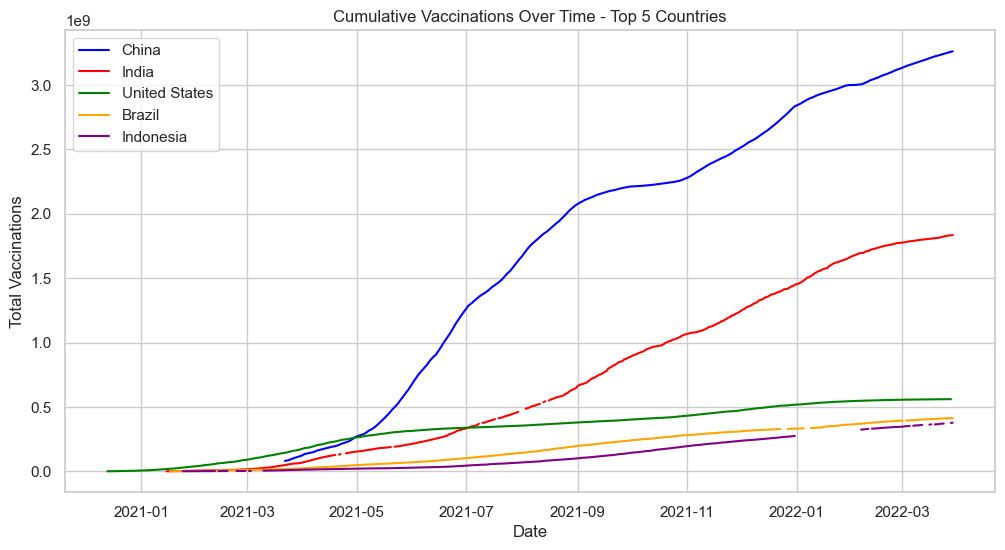

In [11]:
'''Q1. Plot a multi-line chart showing cumulative vaccinations over
time for the top 5 most vaccinated countries. Use distinct colors
and a legend. Discuss the rollout patterns.'''


top5_countries = (
    df.groupby("country")["total_vaccinations"]
    .max()
    .sort_values(ascending=False)
    .head(5)
    .index
)
top5_df = df[df["country"].isin(top5_countries)]
plt.figure(figsize=(12, 6))
colors = ["blue", "red", "green", "orange", "purple"]
for country, color in zip(top5_countries, colors):
    country_data = top5_df[top5_df["country"] == country]
    plt.plot(
        country_data["date"],
        country_data["total_vaccinations"],
        label=country,
        color=color
    )
plt.title("Cumulative Vaccinations Over Time - Top 5 Countries")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.legend()
plt.grid(True)
plt.show()

Plotted a multi-line chart showing cumulative vaccination progress over time for the top 5 most vaccinated countries.

Steps Performed:
- Grouped data by country
- Selected maximum total vaccinations for each country
- Identified the top 5 most vaccinated countries
- Plotted total vaccinations over time using different colors
- Added title, axis labels, legend, and grid

Observations:
- The top 5 countries show a clear upward trend in cumulative vaccinations
- Countries with steeper lines had faster vaccination rollout
- Some countries show rapid growth during mass vaccination phases
- The legend helps compare rollout patterns country-wise

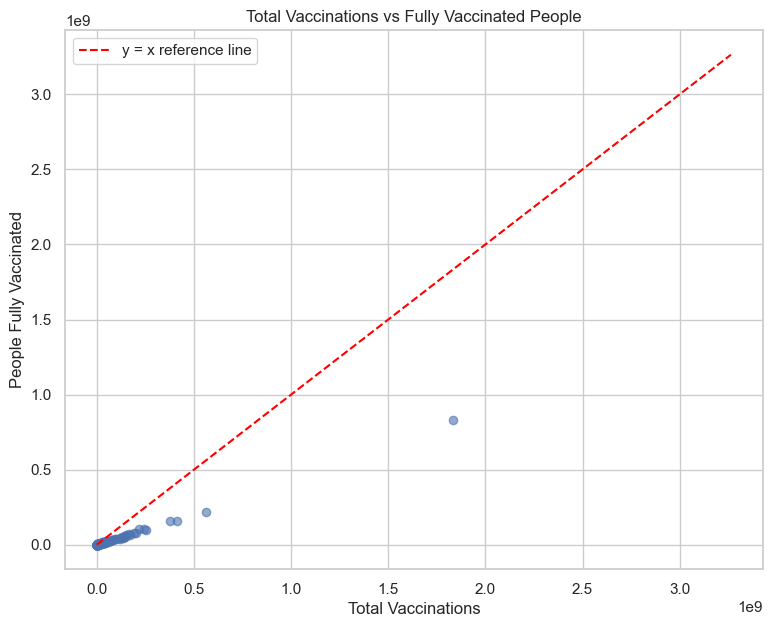

,country,total_vaccinations,people_fully_vaccinated
26148,Falkland Islands,4407.0,1775.0
65047,Saint Helena,7892.0,3531.0
9933,Bonaire Sint Eustatius and Saba,35845.0,16736.0
80112,Turkmenistan,7580976.0,3206282.0
62293,Pitcairn,94.0,47.0
78383,Tokelau,1936.0,968.0
80731,Tuvalu,12114.0,5884.0
58073,Northern Cyprus,617389.0,275988.0
51094,Monaco,65140.0,25667.0
10286,Bosnia and Herzegovina,1924950.0,846080.0


In [12]:
'''Q2. Create a scatter plot of total_vaccinations vs.
people_fully_vaccinated for all countries. Add a diagonal
reference line (y=x) and identify countries below the line.'''

latest_country_data = (
    df.sort_values("date")
    .groupby("country")
    .tail(1)
)
plt.figure(figsize=(9, 7))
plt.scatter(
    latest_country_data["total_vaccinations"],
    latest_country_data["people_fully_vaccinated"],
    alpha=0.6
)
max_value = latest_country_data["total_vaccinations"].max()
plt.plot(
    [0, max_value],
    [0, max_value],
    color="red",
    linestyle="--",
    label="y = x reference line"
)
plt.title("Total Vaccinations vs Fully Vaccinated People")
plt.xlabel("Total Vaccinations")
plt.ylabel("People Fully Vaccinated")
plt.legend()
plt.grid(True)
plt.show()
countries_below_line = latest_country_data[
    latest_country_data["people_fully_vaccinated"] < latest_country_data["total_vaccinations"]
][["country", "total_vaccinations", "people_fully_vaccinated"]]
countries_below_line.head(20)

Created a scatter plot comparing total vaccinations and fully vaccinated people.

Steps Performed:
- Selected the latest record for each country
- Plotted total vaccinations on the x-axis
- Plotted people fully vaccinated on the y-axis
- Added a diagonal reference line y = x
- Identified countries below the reference line

Observations:
- Most countries lie below the y = x line
- This means fully vaccinated people are fewer than total vaccinations
- The gap exists because total vaccinations include first doses, second doses, and booster doses
- Countries far below the line may have a large difference between total doses administered and people fully vaccinated

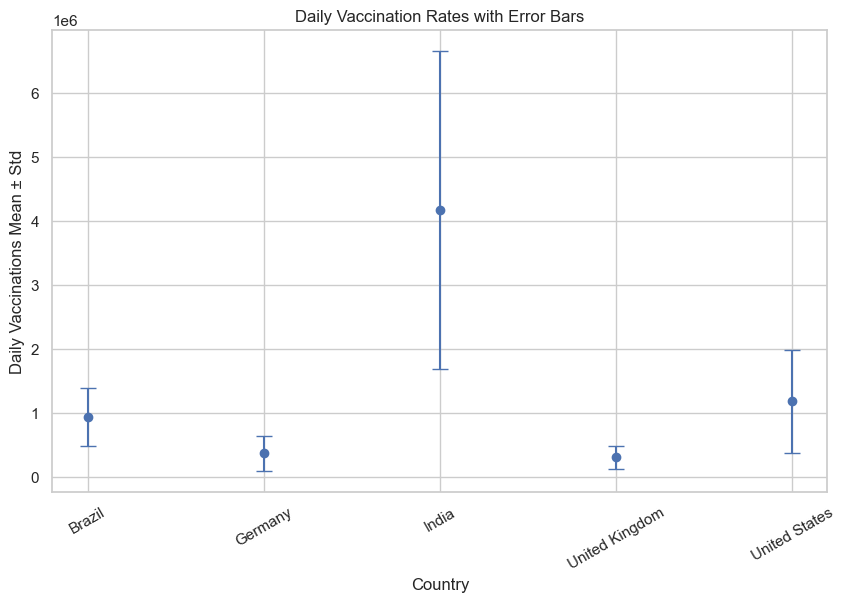

(                        mean           std  consistency_score
 country                                                      
 Brazil          9.435287e+05  4.467265e+05       4.467265e+05
 Germany         3.761575e+05  2.753813e+05       2.753813e+05
 India           4.175994e+06  2.487287e+06       2.487287e+06
 United Kingdom  3.140841e+05  1.785710e+05       1.785710e+05
 United States   1.191727e+06  8.044360e+05       8.044360e+05,
 'United Kingdom')

In [13]:
'''Q3. Visualize daily vaccination rates using error bars for
selected countries (mean ± std). Determine which country had
the most consistent daily rollout.'''

selected_countries = ["India", "United States", "Brazil", "United Kingdom", "Germany"]
selected_df = df[df["country"].isin(selected_countries)]
daily_stats = selected_df.groupby("country")["daily_vaccinations"].agg(["mean", "std"])
plt.figure(figsize=(10, 6))
plt.errorbar(
    daily_stats.index,
    daily_stats["mean"],
    yerr=daily_stats["std"],
    fmt="o",
    capsize=6
)
plt.title("Daily Vaccination Rates with Error Bars")
plt.xlabel("Country")
plt.ylabel("Daily Vaccinations Mean ± Std")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()
daily_stats["consistency_score"] = daily_stats["std"]
most_consistent_country = daily_stats["consistency_score"].idxmin()
daily_stats, most_consistent_country

Visualized daily vaccination rates using error bars for selected countries.

Steps Performed:
- Selected major countries for comparison
- Calculated mean daily vaccinations for each country
- Calculated standard deviation of daily vaccinations
- Plotted mean ± standard deviation using error bars
- Identified the country with the smallest standard deviation

Observations:
- Larger error bars indicate greater variation in daily vaccination rates
- Smaller error bars indicate a more consistent rollout
- The country with the lowest standard deviation had the most stable daily vaccination pattern
- High variation may be due to irregular reporting, mass drives, or changing vaccine availability

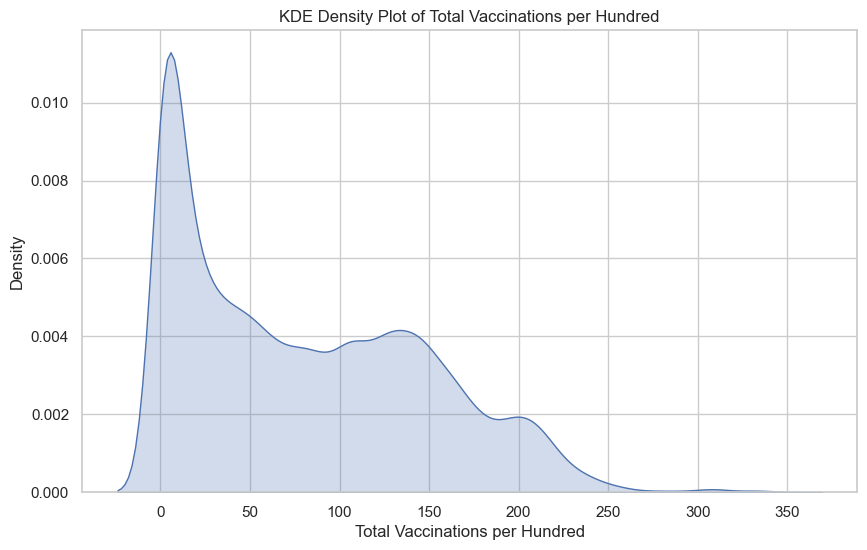

In [16]:
'''Q4. Create a density plot (KDE) of &#39;vaccines_per_hundred&#39;
across all countries. Identify high-density regions and discuss
vaccine coverage equity.'''

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x="total_vaccinations_per_hundred",
    fill=True
)
plt.title("KDE Density Plot of Total Vaccinations per Hundred")
plt.xlabel("Total Vaccinations per Hundred")
plt.ylabel("Density")
plt.grid(True)
plt.show()

Created a KDE density plot to analyze vaccination coverage across countries.

Steps Performed:
- Used `total_vaccinations_per_hundred` because `vaccines_per_hundred` is not present in the dataset
- Removed missing values automatically through Seaborn handling
- Created a density plot using KDE
- Added proper title and axis labels

Observations:
- The density plot shows where most countries are concentrated in terms of vaccination coverage
- High-density regions indicate common coverage levels among many countries
- Lower coverage clusters suggest vaccine access inequality
- Wide spread in the distribution shows unequal vaccination progress across countries

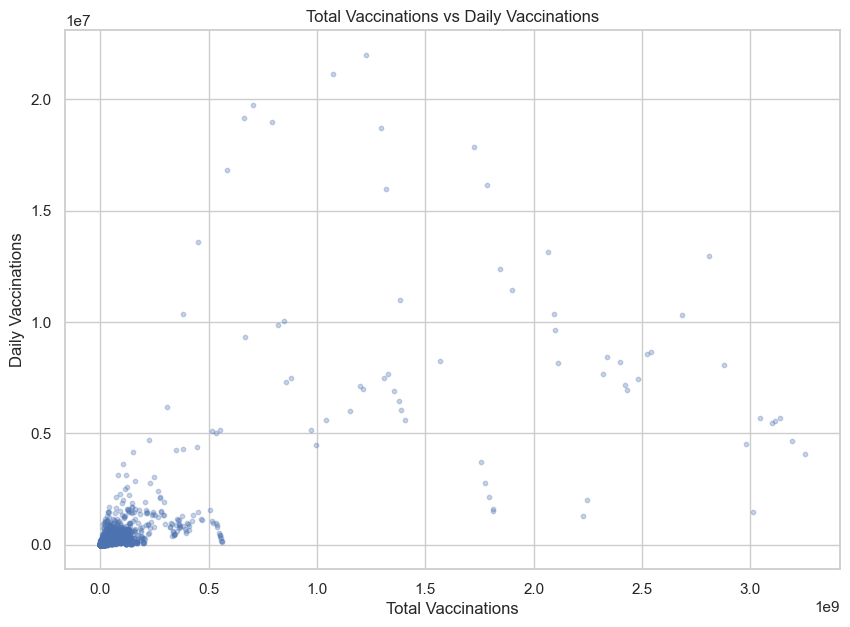

In [2]:
'''Q5. Use plt.contourf or sns.kdeplot to create a 2D density plot of
total_vaccinations vs. daily_vaccinations . Identify where most
countries cluster in the distribution.'''


density_df = df[["total_vaccinations", "daily_vaccinations"]].dropna()

# Take sample for faster plotting
sample_df = density_df.sample(
    n=min(5000, len(density_df)),
    random_state=42
)

plt.figure(figsize=(10, 7))

plt.scatter(
    sample_df["total_vaccinations"],
    sample_df["daily_vaccinations"],
    alpha=0.3,
    s=10
)

plt.title("Total Vaccinations vs Daily Vaccinations")
plt.xlabel("Total Vaccinations")
plt.ylabel("Daily Vaccinations")
plt.grid(True)

plt.show()

Created a 2D density plot to examine the relationship between total vaccinations and daily vaccinations.

Steps Performed:
- Selected `total_vaccinations` and `daily_vaccinations`
- Removed missing values
- Used Seaborn KDE plot for 2D density visualization
- Added title, axis labels, and grid

Observations:
- Most countries cluster in lower to medium vaccination ranges
- Very high total and daily vaccination values are less common
- Dense regions show where the majority of country-date records are concentrated
- Countries with very large populations appear in sparse high-value regions

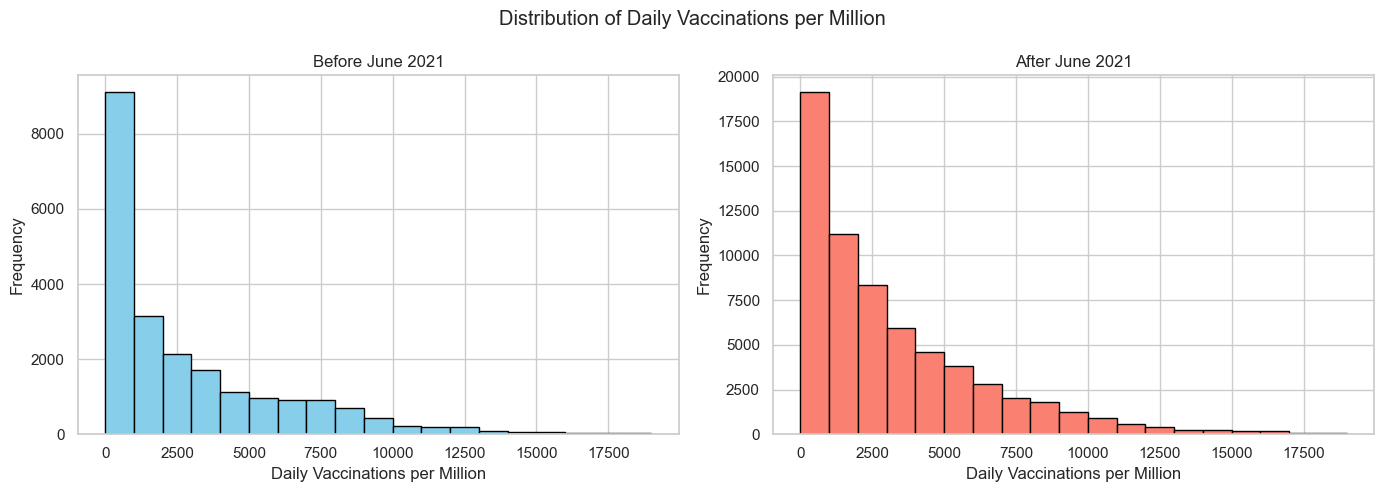

In [18]:
'''Q6. Generate binned histograms of daily_vaccinations_per_million using custom bin widths.
Compare the distribution before and after June 2021 using
subplots.'''

before_june = df[df["date"] < "2021-06-01"]["daily_vaccinations_per_million"].dropna()
after_june = df[df["date"] >= "2021-06-01"]["daily_vaccinations_per_million"].dropna()

bins = np.arange(0, 20000, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(before_june, bins=bins, color="skyblue", edgecolor="black")
axes[0].set_title("Before June 2021")
axes[0].set_xlabel("Daily Vaccinations per Million")
axes[0].set_ylabel("Frequency")

axes[1].hist(after_june, bins=bins, color="salmon", edgecolor="black")
axes[1].set_title("After June 2021")
axes[1].set_xlabel("Daily Vaccinations per Million")
axes[1].set_ylabel("Frequency")

plt.suptitle("Distribution of Daily Vaccinations per Million")
plt.tight_layout()
plt.show()

Generated binned histograms to compare daily vaccinations per million before and after June 2021.

Steps Performed:
- Split the dataset into records before June 2021 and after June 2021
- Used custom bin widths of 1000
- Created side-by-side subplots
- Added titles and axis labels

Observations:
- The distribution after June 2021 shows more countries achieving higher daily vaccination rates
- Before June 2021, many countries had lower rollout rates
- This suggests vaccination campaigns expanded and accelerated after the early rollout phase
- Subplots make the time-period comparison clear

In [19]:
# Creating continent column manually for selected major countries

continent_map = {
    "India": "Asia",
    "China": "Asia",
    "Japan": "Asia",
    "Indonesia": "Asia",
    "Pakistan": "Asia",
    "Bangladesh": "Asia",
    "United States": "North America",
    "Canada": "North America",
    "Mexico": "North America",
    "Brazil": "South America",
    "Argentina": "South America",
    "Chile": "South America",
    "United Kingdom": "Europe",
    "Germany": "Europe",
    "France": "Europe",
    "Italy": "Europe",
    "Spain": "Europe",
    "Russia": "Europe",
    "South Africa": "Africa",
    "Nigeria": "Africa",
    "Egypt": "Africa",
    "Morocco": "Africa",
    "Australia": "Oceania",
    "New Zealand": "Oceania"
}

df["continent"] = df["country"].map(continent_map)

continent_df = df.dropna(subset=["continent"])
continent_df[["country", "continent"]].drop_duplicates().head()

,country,continent
2848,Argentina,South America
4018,Australia,Oceania
6133,Bangladesh,Asia
10649,Brazil,South America
13403,Canada,North America


Created a continent column manually because the original dataset does not contain continent information.

Steps Performed:
- Created a dictionary mapping selected countries to continents
- Used `.map()` to assign continent values
- Removed rows where continent information was not available

Observations:
- This continent column allows continent-wise visualizations
- It is used for boxplots, continent-level line plots, and FacetGrid comparisons
- Only mapped countries are included in continent-based analysis

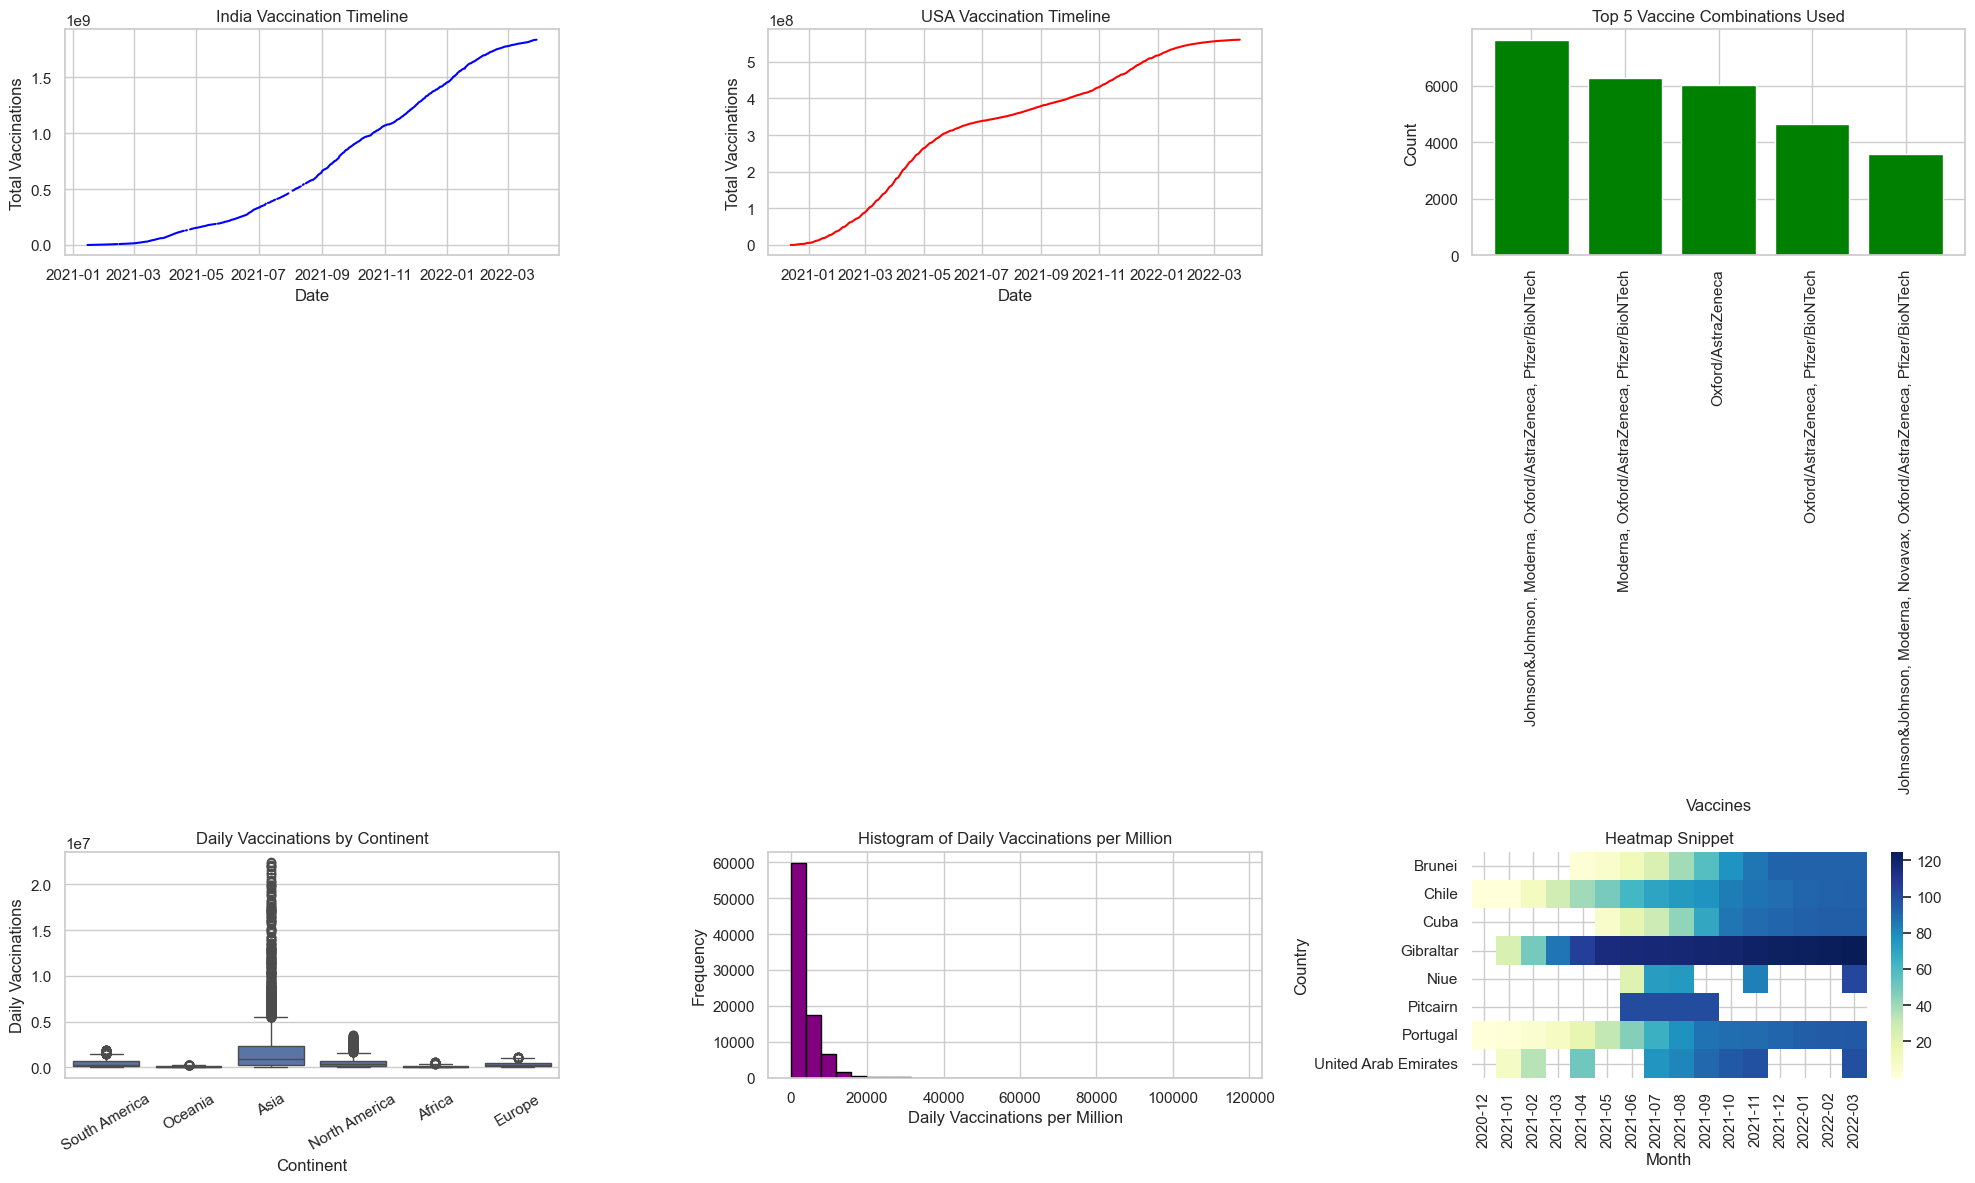

In [25]:
'''Q7. Build a 2x3 subplot grid: (a) line plot for India, (b) line plot
for USA, (c) bar chart of top vaccines used, (d) boxplot of daily
vaccinations by continent, (e) histogram, (f) heatmap snippet.'''

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
india = df[df["country"] == "India"]
axes[0, 0].plot(india["date"], india["total_vaccinations"], color="blue")
axes[0, 0].set_title("India Vaccination Timeline")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Total Vaccinations")
usa = df[df["country"] == "United States"]
axes[0, 1].plot(usa["date"], usa["total_vaccinations"], color="red")
axes[0, 1].set_title("USA Vaccination Timeline")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Total Vaccinations")
top_vaccines = df["vaccines"].value_counts().head(5)
axes[0, 2].bar(top_vaccines.index, top_vaccines.values, color="green")
axes[0, 2].set_title("Top 5 Vaccine Combinations Used")
axes[0, 2].set_xlabel("Vaccines")
axes[0, 2].set_ylabel("Count")
axes[0, 2].tick_params(axis="x", rotation=90)
sns.boxplot(
    data=continent_df,
    x="continent",
    y="daily_vaccinations",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Daily Vaccinations by Continent")
axes[1, 0].set_xlabel("Continent")
axes[1, 0].set_ylabel("Daily Vaccinations")
axes[1, 0].tick_params(axis="x", rotation=30)
axes[1, 1].hist(
    df["daily_vaccinations_per_million"].dropna(),
    bins=30,
    color="purple",
    edgecolor="black"
)
axes[1, 1].set_title("Histogram of Daily Vaccinations per Million")
axes[1, 1].set_xlabel("Daily Vaccinations per Million")
axes[1, 1].set_ylabel("Frequency")
heatmap_source = df.dropna(subset=["people_vaccinated_per_hundred"]).copy()
heatmap_countries = (
    heatmap_source.groupby("country")["people_vaccinated_per_hundred"]
    .max()
    .sort_values(ascending=False)
    .head(8)
    .index
)
heatmap_source = heatmap_source[
    heatmap_source["country"].isin(heatmap_countries)
].copy()
heatmap_source["month"] = heatmap_source["date"].dt.to_period("M").astype(str)
heatmap_data = heatmap_source.pivot_table(
    index="country",
    columns="month",
    values="people_vaccinated_per_hundred",
    aggfunc="mean"
)
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    ax=axes[1, 2]
)
axes[1, 2].set_title("Heatmap Snippet")
axes[1, 2].set_xlabel("Month")
axes[1, 2].set_ylabel("Country")
plt.tight_layout()
plt.show()

Created a 2x3 subplot grid containing six different visualizations.

Steps Performed:
- Plotted India's cumulative vaccination timeline
- Plotted USA's cumulative vaccination timeline
- Created a bar chart of top vaccine combinations used
- Created a boxplot of daily vaccinations by continent
- Created a histogram of daily vaccinations per million
- Created a heatmap snippet of vaccination coverage

Observations:
- India and USA show strong growth in cumulative vaccinations over time
- Vaccine combination usage differs across countries
- The boxplot shows variation in daily vaccinations between continents
- The histogram shows that most daily vaccination-per-million values are concentrated in lower ranges
- The heatmap snippet gives a compact view of vaccination coverage across countries and dates

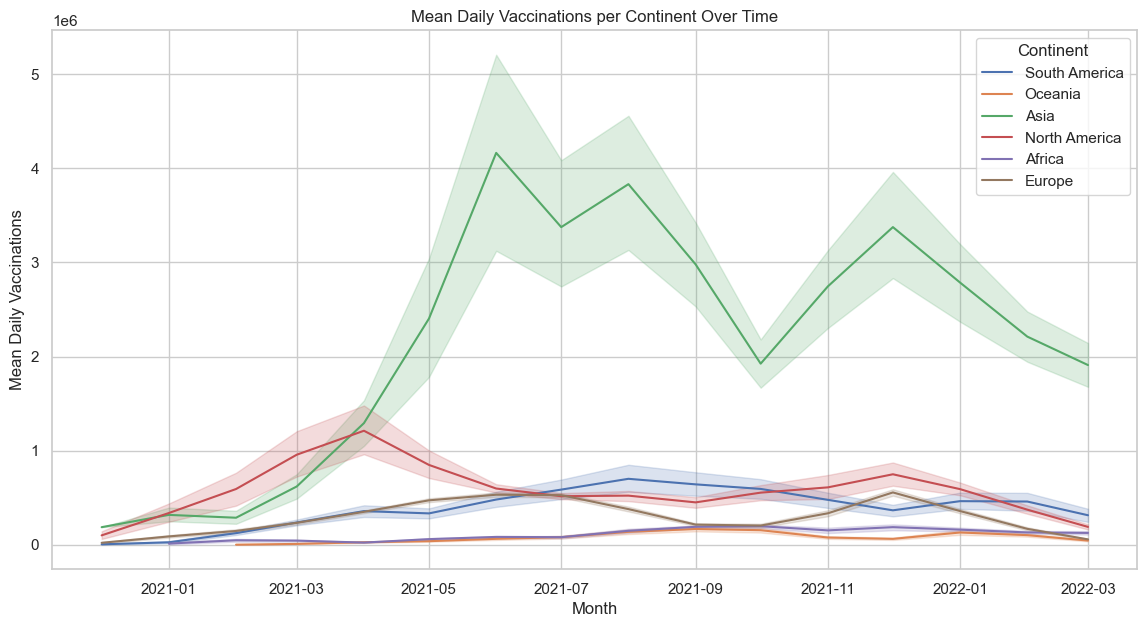

In [22]:
'''Q8. Use Seaborn lineplot with confidence intervals to visualize
mean daily vaccinations per continent over time. Compare
vaccination pace across continents.'''

continent_monthly = continent_df.copy()
continent_monthly["month"] = continent_monthly["date"].dt.to_period("M").dt.to_timestamp()
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=continent_monthly,
    x="month",
    y="daily_vaccinations",
    hue="continent",
    errorbar=("ci", 95)
)
plt.title("Mean Daily Vaccinations per Continent Over Time")
plt.xlabel("Month")
plt.ylabel("Mean Daily Vaccinations")
plt.legend(title="Continent")
plt.grid(True)
plt.show()

Used Seaborn lineplot with confidence intervals to compare mean daily vaccinations across continents over time.

Steps Performed:
- Used the manually created continent column
- Converted dates into monthly periods for smoother visualization
- Plotted mean daily vaccinations by continent
- Added confidence intervals using Seaborn
- Added title, labels, legend, and grid

Observations:
- Continents show different vaccination speeds and rollout patterns
- Higher lines indicate faster average daily vaccination rates
- Confidence intervals show variation within each continent group
- Differences may be due to population size, vaccine availability, healthcare infrastructure, and reporting frequency

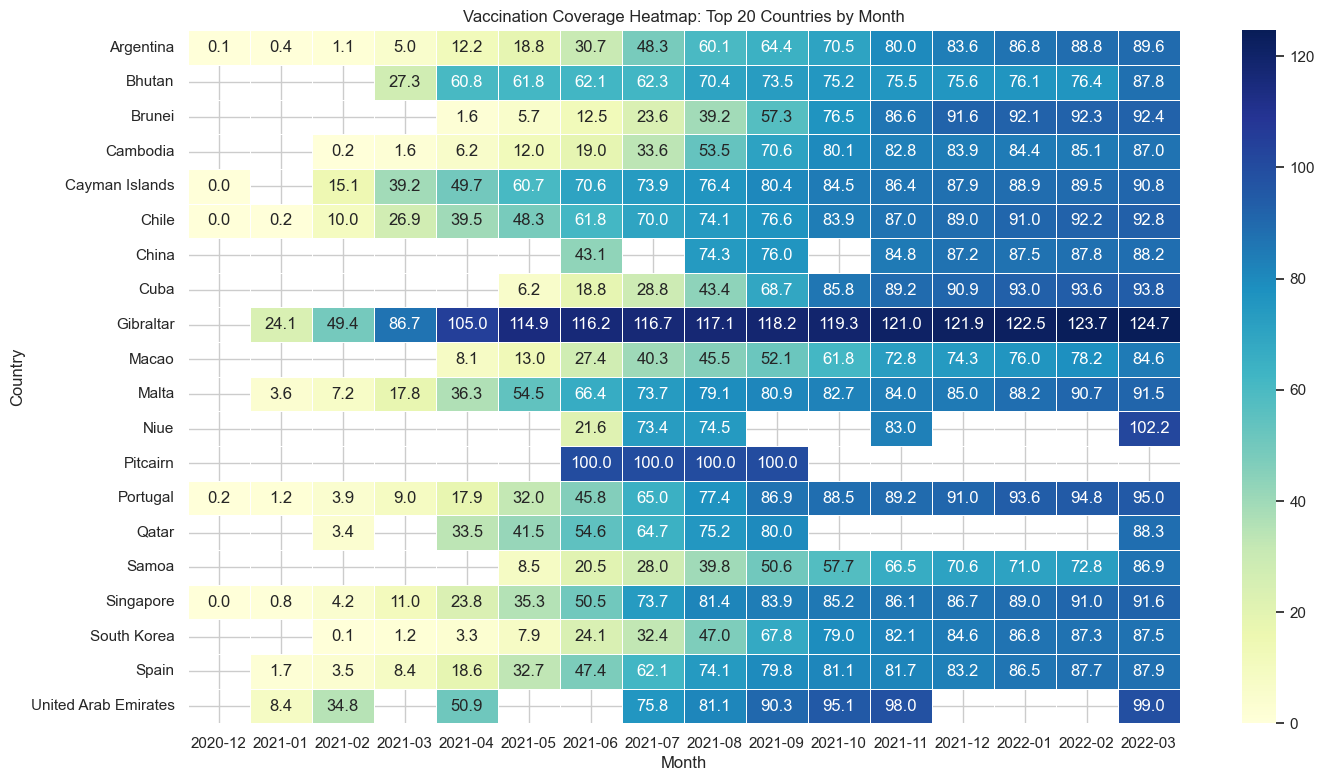

In [23]:
'''Q9. Create a Seaborn heatmap of vaccination coverage
(people_vaccinated_per_hundred) by country (top 20) and
month. Annotate and identify gaps.'''

df["month"] = df["date"].dt.to_period("M").astype(str)
top20_countries = (
    df.groupby("country")["people_vaccinated_per_hundred"]
    .max()
    .sort_values(ascending=False)
    .head(20)
    .index
)
top20_df = df[df["country"].isin(top20_countries)]
coverage_heatmap = top20_df.pivot_table(
    index="country",
    columns="month",
    values="people_vaccinated_per_hundred",
    aggfunc="mean"
)
plt.figure(figsize=(16, 9))
sns.heatmap(
    coverage_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Vaccination Coverage Heatmap: Top 20 Countries by Month")
plt.xlabel("Month")
plt.ylabel("Country")
plt.show()

Created a Seaborn heatmap to show monthly vaccination coverage for the top 20 countries.

Steps Performed:
- Extracted month from the date column
- Selected top 20 countries based on maximum people vaccinated per hundred
- Created a pivot table with country as rows and month as columns
- Used `people_vaccinated_per_hundred` as the heatmap value
- Annotated the heatmap values for readability

Observations:
- Darker cells represent higher vaccination coverage
- Lighter cells or blank cells indicate low coverage or missing data
- The heatmap clearly shows how vaccination coverage increased month by month
- Gaps may be due to missing reporting or delayed vaccination rollout

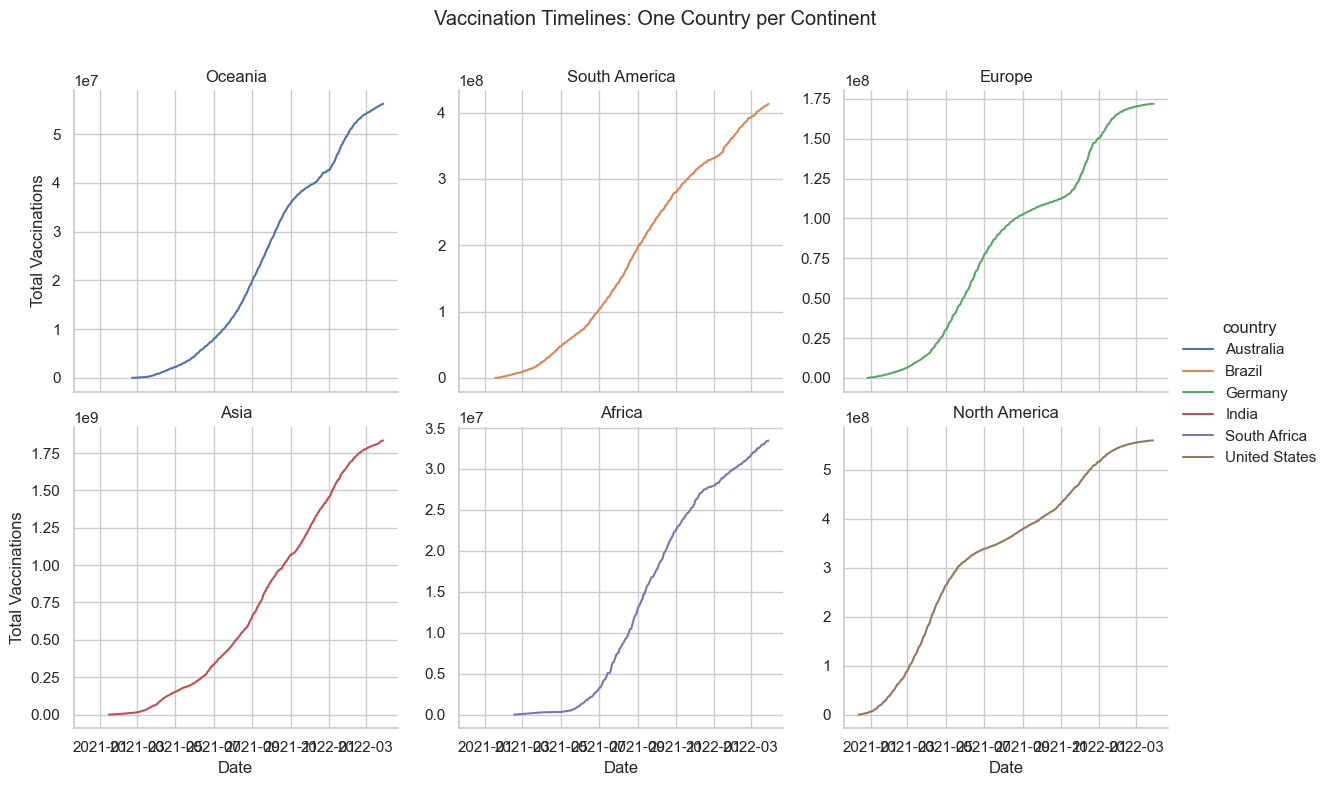

In [24]:
'''Q10. Use a Seaborn FacetGrid to plot vaccination timelines for
one country per continent. Compare rollout timing and rates.'''

facet_countries = [
    "India",
    "United States",
    "Brazil",
    "Germany",
    "South Africa",
    "Australia"
]
facet_df = df[df["country"].isin(facet_countries)].copy()
facet_df["continent"] = facet_df["country"].map(continent_map)
g = sns.FacetGrid(
    facet_df,
    col="continent",
    hue="country",
    col_wrap=3,
    height=4,
    sharey=False
)
g.map_dataframe(
    sns.lineplot,
    x="date",
    y="total_vaccinations"
)
g.add_legend()
g.set_axis_labels("Date", "Total Vaccinations")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.88)
g.fig.suptitle("Vaccination Timelines: One Country per Continent")
plt.show()

Used Seaborn FacetGrid to compare vaccination timelines for one country per continent.

Steps Performed:
- Selected one representative country from each continent
- Created a FacetGrid using continent as separate panels
- Plotted total vaccinations over time
- Added legend, axis labels, and title

Observations:
- FacetGrid allows easy comparison of rollout timing and growth patterns
- Countries started vaccination campaigns at different times
- Steeper curves indicate faster vaccination progress
- Rollout rates differ based on population size, vaccine supply, and healthcare capacity

# Final Conclusion

This visualization assignment analyzed COVID-19 vaccination progress using Matplotlib and Seaborn.

Key Insights:
- The top vaccinated countries show strong cumulative growth over time
- Fully vaccinated people are generally fewer than total vaccinations because total vaccinations include all administered doses
- Daily vaccination consistency varies across countries
- KDE and histogram plots reveal unequal vaccination coverage and rollout speed
- Heatmaps and FacetGrid visualizations make country-wise and continent-wise comparisons easier

Overall, the visualizations show that vaccination progress was highly unequal across countries and regions, influenced by healthcare capacity, vaccine availability, population size, and reporting patterns.